In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

In [3]:
train_dir = "seg_train"
test_dir = "seg_test"

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
VAL_SPLIT = 0.1

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=VAL_SPLIT,
    subset="training",
    shuffle=True,
    seed=42
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=VAL_SPLIT,
    subset="validation",
    shuffle=False,
    seed=42
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 14034 files belonging to 6 classes.
Using 12631 files for training.
Found 14034 files belonging to 6 classes.
Using 1403 files for validation.
Found 3000 files belonging to 6 classes.


In [5]:
normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

val_dataset = val_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

test_dataset = test_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [6]:
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),

    layers.Dropout(0.2),
    layers.Dense(6)
])

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,735,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,792,390 (18.28 MB)

 Trainable params: 4,792,070 (18.28 MB)

 Non-trainable params: 320 (1.25 KB)

In [8]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("Improved model compiled successfully.")

Improved model compiled successfully.


In [9]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10


C:\Users\mhmwd\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


395/395 ━━━━━━━━━━━━━━━━━━━━ 279s 691ms/step - accuracy: 0.5299 - loss: 2.1812 - val_accuracy: 0.7976 - val_loss: 0.9225
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 283s 716ms/step - accuracy: 0.6575 - loss: 0.9663 - val_accuracy: 0.8261 - val_loss: 0.7129
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 273s 690ms/step - accuracy: 0.7259 - loss: 0.7380 - val_accuracy: 0.9038 - val_loss: 0.3005
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 283s 716ms/step - accuracy: 0.7659 - loss: 0.6440 - val_accuracy: 0.9123 - val_loss: 0.2775
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 294s 743ms/step - accuracy: 0.7927 - loss: 0.5542 - val_accuracy: 0.6094 - val_loss: 1.9918
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 299s 757ms/step - accuracy: 0.8299 - loss: 0.4494 - val_accuracy: 0.3685 - val_loss: 6.2425
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 291s 735ms/step - accuracy: 0.8459 - loss: 0.4235 - val_accuracy: 0.9351 - val_loss: 0.1999
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 288s 728ms/step - accuracy: 0.8618 - loss: 0.37

In [10]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.7503 - loss: 0.7527
Test Loss: 0.7527
Test Accuracy: 0.7503


In [11]:
from sklearn.metrics import confusion_matrix

# Get the true labels and model predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[322   6   3  17  10  79]
 [  1 437   3   6   1  26]
 [ 12   5 337 152  27  20]
 [ 13   4  42 453  10   3]
 [ 25   4  70 131 266  14]
 [ 42  10   1   7   5 436]]


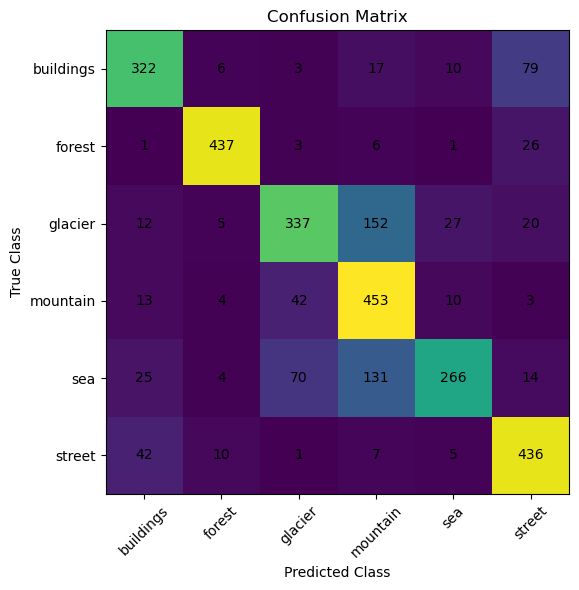

In [13]:
plt.figure(figsize=(8, 6))

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [14]:
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# Store a few misclassified images
misclassified = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    true_labels = np.argmax(labels.numpy(), axis=1)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(len(images)):
        if true_labels[i] != predicted_labels[i]:
            misclassified.append((
                images[i].numpy(),
                true_labels[i],
                predicted_labels[i]
            ))

    if len(misclassified) >= 30:
        break

print("Number of misclassified samples collected:", len(misclassified))

Number of misclassified samples collected: 30


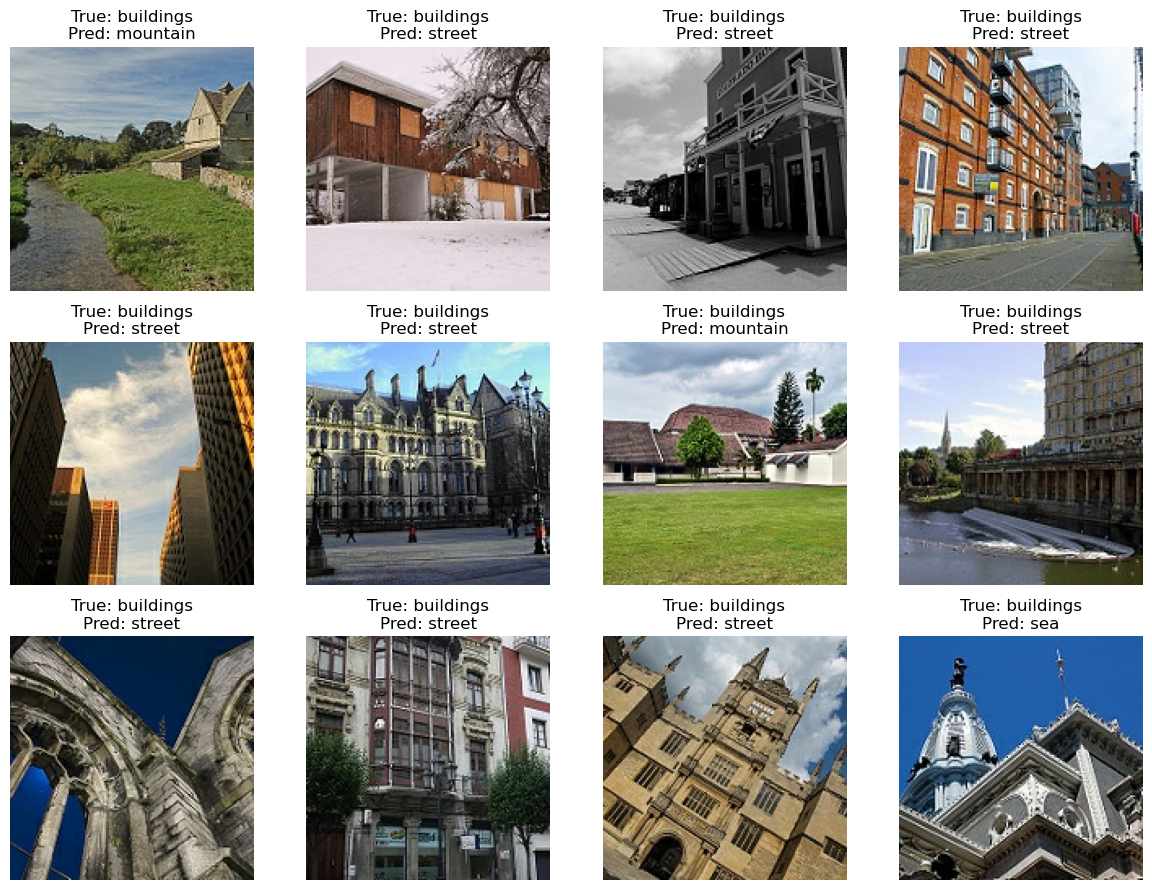

In [15]:
plt.figure(figsize=(12, 9))

for i, (image, true_label, predicted_label) in enumerate(misclassified[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(image)
    plt.title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[predicted_label]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
target_errors = [
    ('glacier', 'mountain'),
    ('sea', 'mountain'),
    ('buildings', 'street')
]

selected_errors = {
    pair: []
    for pair in target_errors
}

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    true_labels = np.argmax(labels.numpy(), axis=1)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(len(images)):
        true_class = class_names[true_labels[i]]
        predicted_class = class_names[predicted_labels[i]]

        pair = (true_class, predicted_class)

        if pair in selected_errors and len(selected_errors[pair]) < 4:
            selected_errors[pair].append(
                (images[i].numpy(), true_class, predicted_class)
            )

    if all(len(selected_errors[pair]) >= 4 for pair in target_errors):
        break

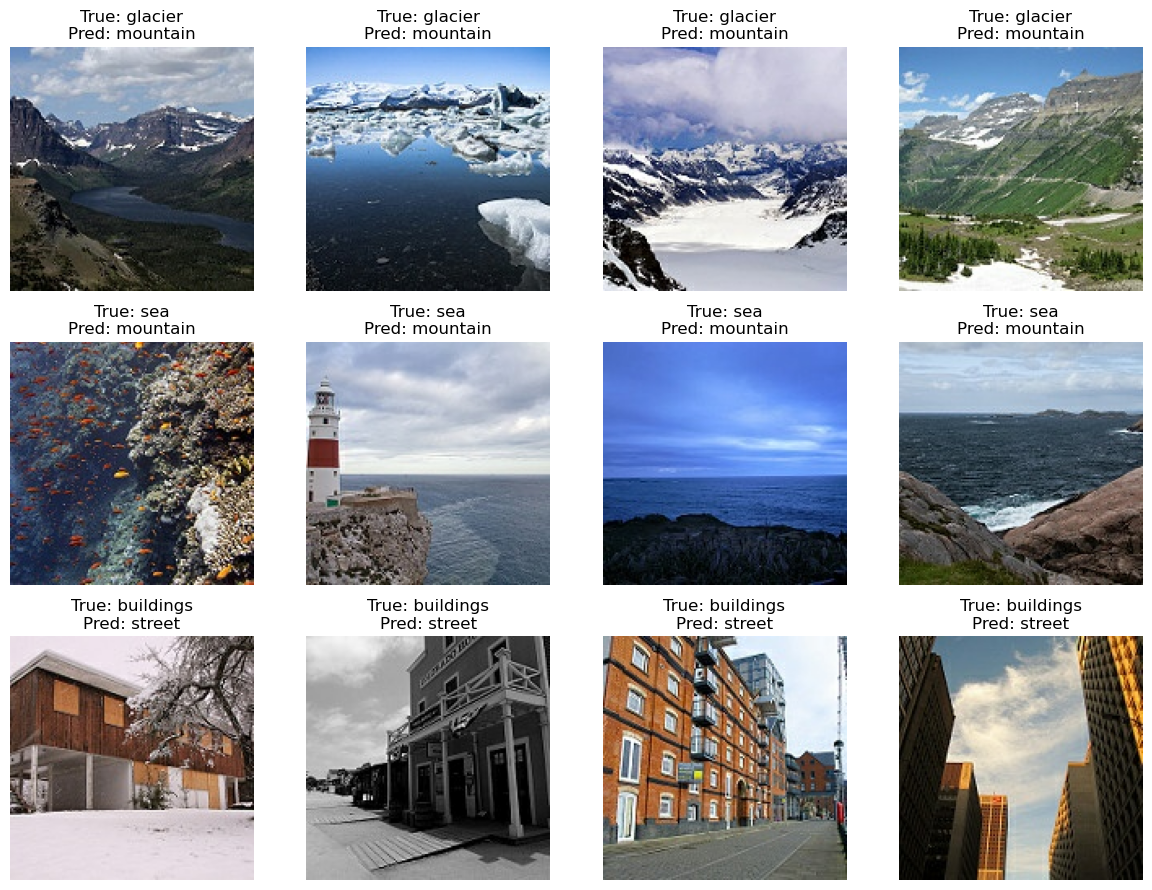

In [17]:
plt.figure(figsize=(12, 9))

plot_index = 1

for pair in target_errors:
    for image, true_class, predicted_class in selected_errors[pair]:

        plt.subplot(3, 4, plot_index)
        plt.imshow(image)

        plt.title(
            f"True: {true_class}\nPred: {predicted_class}"
        )

        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

In [18]:
light_model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),

    layers.Dense(6)
])

In [19]:
light_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("Light model compiled successfully.")

Light model compiled successfully.


In [20]:
light_history = light_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10


C:\Users\mhmwd\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


395/395 ━━━━━━━━━━━━━━━━━━━━ 283s 701ms/step - accuracy: 0.5958 - loss: 2.0059 - val_accuracy: 0.4048 - val_loss: 1.6249
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 277s 700ms/step - accuracy: 0.7748 - loss: 0.6717 - val_accuracy: 0.8952 - val_loss: 0.3994
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 270s 683ms/step - accuracy: 0.8533 - loss: 0.4179 - val_accuracy: 0.9608 - val_loss: 0.1872
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 271s 686ms/step - accuracy: 0.8799 - loss: 0.3571 - val_accuracy: 0.9608 - val_loss: 0.1535
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 275s 694ms/step - accuracy: 0.9295 - loss: 0.2044 - val_accuracy: 0.9629 - val_loss: 0.1847
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 277s 701ms/step - accuracy: 0.9515 - loss: 0.1514 - val_accuracy: 0.9259 - val_loss: 0.2246
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 279s 706ms/step - accuracy: 0.9595 - loss: 0.1283 - val_accuracy: 0.8432 - val_loss: 0.6688
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 317s 692ms/step - accuracy: 0.9542 - loss: 0.14

In [22]:
test_loss, test_accuracy = light_model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.6547 - loss: 1.8010
Test Loss: 1.8010
Test Accuracy: 0.6547


In [23]:
gap_model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dense(6)
])

gap_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,870 (237.77 KB)

 Trainable params: 60,870 (237.77 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
gap_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("Global Average Pooling model compiled successfully.")

Global Average Pooling model compiled successfully.


In [25]:
gap_history = gap_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 134s 327ms/step - accuracy: 0.4556 - loss: 1.2861 - val_accuracy: 0.4148 - val_loss: 1.4018
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 129s 326ms/step - accuracy: 0.6020 - loss: 0.9787 - val_accuracy: 0.8289 - val_loss: 0.6648
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 128s 323ms/step - accuracy: 0.6643 - loss: 0.8541 - val_accuracy: 0.7847 - val_loss: 0.6571
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 128s 325ms/step - accuracy: 0.6866 - loss: 0.8040 - val_accuracy: 0.8275 - val_loss: 0.6267
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 128s 323ms/step - accuracy: 0.7140 - loss: 0.7488 - val_accuracy: 0.8011 - val_loss: 0.5540
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 128s 322ms/step - accuracy: 0.7277 - loss: 0.7178 - val_accuracy: 0.7919 - val_loss: 0.6888
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 128s 324ms/step - accuracy: 0.7428 - loss: 0.6830 - val_accuracy: 0.8411 - val_loss: 0.4828
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 128s 324ms/step - accuracy: 0.7557 -

In [26]:
test_loss, test_accuracy = gap_model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.7747 - loss: 0.5996  
Test Loss: 0.5996
Test Accuracy: 0.7747


In [27]:
inputs = layers.Input(shape=(150, 150, 3))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
shortcut = x

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.Add()([x, shortcut])

x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(64, activation='relu')(x)

outputs = layers.Dense(6)(x)

residual_model = tf.keras.Model(inputs=inputs, outputs=outputs)

residual_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 150, 150,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 75, 75,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 75, 75,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 75, 75,    │     36,928 │ conv2d_10[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 75, 75,    │          0 │ conv2d_11[0][0],  │
│                     │ 64)               │            │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 37, 37,    │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 37, 37,    │     36,928 │ max_pooling2d_7[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_12[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 6)         │        390 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 97,798 (382.02 KB)

 Trainable params: 97,798 (382.02 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
residual_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("Residual model compiled successfully.")

Residual model compiled successfully.


In [29]:
residual_history = residual_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 288s 718ms/step - accuracy: 0.4582 - loss: 1.2721 - val_accuracy: 0.8104 - val_loss: 0.7093
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 282s 714ms/step - accuracy: 0.6094 - loss: 0.9636 - val_accuracy: 0.7384 - val_loss: 0.8733
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 283s 716ms/step - accuracy: 0.6824 - loss: 0.8230 - val_accuracy: 0.8232 - val_loss: 0.6098
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 286s 724ms/step - accuracy: 0.7265 - loss: 0.7317 - val_accuracy: 0.7733 - val_loss: 0.6426
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 288s 729ms/step - accuracy: 0.7473 - loss: 0.6733 - val_accuracy: 0.8147 - val_loss: 0.5306
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 285s 720ms/step - accuracy: 0.7705 - loss: 0.6272 - val_accuracy: 0.8076 - val_loss: 0.5098
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 286s 723ms/step - accuracy: 0.7797 - loss: 0.5939 - val_accuracy: 0.7313 - val_loss: 0.6289
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 284s 718ms/step - accuracy: 0.7972 -

In [30]:
test_loss, test_accuracy = residual_model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.8177 - loss: 0.4943
Test Loss: 0.4943
Test Accuracy: 0.8177
